# Execution, Costs and Temporal Validation

**Master's Thesis in Data Science - Chapter 5.7 and 5.5: the measurement apparatus**

Notebook `02` established that the predictors only know the past. That is necessary but not
sufficient: a causal feature set evaluated through an optimistic backtester still produces fiction.
This notebook audits the **measurement apparatus** itself - how a signal becomes a filled position,
what that position costs, and how the resulting performance is partitioned in time so that a number
reported as "out of sample" genuinely is.

## 1. Executive summary

**Objective.** Make every mechanism that converts a signal into a performance number explicit and
measurable: execution timing, fees, slippage, funding, turnover, and the walk-forward geometry with
its purge and embargo.

**The central claim of this notebook.** In this asset class, at this frequency, **the cost model is
not a detail applied at the end - it is the dominant term.** A rule that looks profitable before costs
routinely loses money after them, and the crossing point is a property of turnover, not of the
signal's cleverness. Section 5 measures that crossing point directly.

**What is verified here.**

| # | Property | How it is tested |
|---|----------|------------------|
| E1 | Execution is strictly delayed - a signal at the close of *t* fills at the open of *t+1* | Ledger inspection on a real trade |
| E2 | The net return decomposes exactly into gross, fee, slippage and funding | Reconciliation to machine precision |
| E3 | Funding is charged from the venue's own schedule, never assumed to be zero | `require_funding` raises rather than substituting |
| E4 | Walk-forward folds are chronological, disjoint and purged/embargoed | Boundary and overlap checks on all folds |
| E5 | No fold reaches the frozen holdout | `assert_folds_exclude_holdout` fails closed |
| E6 | Fixed baselines are repriced on the identical bars a strategy is judged on | Shared ledger coverage |

**Temporal separation.** Development `2020-01-01` .. `2025-12-31 23:00 UTC`; frozen holdout
`[2026-01-01, 2026-07-01)`. Every fold generated here is asserted to end strictly before the holdout.

### Research questions

- **RQ1.** Does the engine's next-bar execution rule hold on every bar, including reversals?
- **RQ2.** How much of a strategy's gross return is consumed by fees, slippage and funding, and in
  what proportion?
- **RQ3.** At what turnover does a positive gross edge become a negative net result?
- **RQ4.** What does funding actually contribute to a perpetual-futures strategy, and does its sign
  depend on the side held?
- **RQ5.** Does the walk-forward geometry produce genuinely disjoint out-of-sample windows, and how
  much data do purge and embargo cost?
- **RQ6.** What must a searched strategy beat before its result means anything?

## 2. Configuration, data and the feature substrate

**Method.** We reuse the exact configuration and causal feature set audited in notebook `02`, so that
any difference in results here is attributable to the execution and cost layer alone and not to a
different input.

In [1]:
import os
import sys
from pathlib import Path

_root = Path.cwd()
while not (_root / "pyproject.toml").exists() and _root != _root.parent:
    _root = _root.parent
os.chdir(_root)
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))
REPO_ROOT = _root
print(f"Repository root: {REPO_ROOT}")

Repository root: C:\Users\alexc\OneDrive\Escritorio\tfm_algorithmic_trading


In [2]:
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
from matplotlib.patches import Patch

from perp_lab import __version__ as perp_lab_version
from perp_lab.backtesting import run_backtest
from perp_lab.config import Paths, load_data_contract, load_experiment_config, load_settings
from perp_lab.eda import DataLake
from perp_lab.eda.datasets import assert_no_holdout
from perp_lab.features import build_feature_frame, feature_columns, resolve_feature_set
from perp_lab.reporting import (
    ArtifactContext,
    apply_house_style,
    save_figure,
    save_table,
)
from perp_lab.strategies.baselines import default_baselines
from perp_lab.utils.timeutils import timeframe_to_timedelta
from perp_lab.validation.walk_forward import (
    assert_folds_exclude_holdout,
    generate_walk_forward,
    split_fold,
)

apply_house_style()

SETTINGS = load_settings()
SEED = SETTINGS.seed
np.random.seed(SEED)

CONTRACT = load_data_contract()
EXP = load_experiment_config()
PATHS = Paths()
LAKE = DataLake(CONTRACT, PATHS)

SYMBOLS = list(CONTRACT.symbol_names())
PRIMARY_TF = EXP.timeframes.primary
HOLDOUT_START = LAKE.holdout_start
DAYS_PER_YEAR = EXP.annualization_days
FEE_BPS = EXP.costs.taker_fee_bps
SLIP_BPS = EXP.costs.slippage.baseline_bps
FIG_DPI = 300

print("Environment")
print(f"  Python      : {platform.python_version()} | perp_lab {perp_lab_version}")
print(
    f"  polars      : {pl.__version__} | numpy {np.__version__} | matplotlib {matplotlib.__version__}"
)
print(f"  random seed : {SEED}")
print("Cost contract (PROVISIONAL - ADR 0005)")
print(f"  fee model        : {EXP.costs.fee_model}")
print(f"  taker fee        : {FEE_BPS:.2f} bps per side")
print(f"  slippage         : {SLIP_BPS:.2f} bps per side")
print(f"  round-trip floor : {2 * (FEE_BPS + SLIP_BPS):.2f} bps")
print(f"  funding          : {EXP.costs.funding.treatment}, aligned {EXP.costs.funding.align}")
print(f"  execution        : {EXP.strategies.execution}")

Environment
  Python      : 3.12.3 | perp_lab 0.1.0
  polars      : 1.43.1 | numpy 2.5.1 | matplotlib 3.11.1
  random seed : 42
Cost contract (PROVISIONAL - ADR 0005)
  fee model        : taker
  taker fee        : 4.00 bps per side
  slippage         : 1.00 bps per side
  round-trip floor : 10.00 bps
  funding          : realized, aligned as_of_past
  execution        : next_bar_open


In [3]:
NB_ID = "03_backtesting_and_walk_forward"
ctx = ArtifactContext(
    notebook=NB_ID,
    figures_dir=PATHS.reports_root / "figures" / "backtest",
    tables_dir=PATHS.reports_root / "tables" / "backtest",
    metadata_dir=PATHS.reports_root / "metadata" / "backtest",
    config={
        "seed": SEED,
        "experiment_version": EXP.version,
        "primary_timeframe": PRIMARY_TF,
        "fee_bps_per_side": FEE_BPS,
        "slippage_bps_per_side": SLIP_BPS,
        "days_per_year": DAYS_PER_YEAR,
        "holdout_start": HOLDOUT_START.isoformat(),
    },
    repo_root=".",
)


def show(fig, name, caption=""):
    save_figure(fig, name, ctx, caption=caption, dpi=FIG_DPI)
    display(fig)
    plt.close(fig)


SPECS = resolve_feature_set(EXP.features.feature_set, ensure_sma=())
FEATURE_COLS = feature_columns(SPECS)

BARS: dict[str, pl.DataFrame] = {}
FEAT: dict[str, pl.DataFrame] = {}
FUND: dict[str, pl.DataFrame] = {}
for sym in SYMBOLS:
    ds = LAKE.load_klines(sym, PRIMARY_TF, partition="development")
    fds = LAKE.load_funding(sym, partition="development")
    assert_no_holdout(ds.frame, HOLDOUT_START, time_col="open_time")
    assert_no_holdout(fds.frame, HOLDOUT_START, time_col="funding_time")
    BARS[sym] = ds.frame
    FUND[sym] = fds.frame
    FEAT[sym], _ = build_feature_frame(ds.frame, SPECS, holdout_start=HOLDOUT_START)
    ctx.datasets[ds.dataset_id] = ds.sha256 or ""
    ctx.datasets[fds.dataset_id] = fds.sha256 or ""

SYM = SYMBOLS[0]
DEV_START = BARS[SYM].select(pl.col("open_time").min()).item()
DEV_END = BARS[SYM].select(pl.col("open_time").max()).item()
ctx.period = f"{DEV_START} .. {DEV_END} (development, holdout excluded)"
print(f"Bars per asset : {BARS[SYM].height:,} ({PRIMARY_TF})")
print(f"Funding rows   : {FUND[SYM].height:,} per asset")
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Span           : {DEV_START} .. {DEV_END}")
print(f"HOLDOUT GATE   : PASSED (nothing at or after {HOLDOUT_START.isoformat()})")

Bars per asset : 52,608 (1h)
Funding rows   : 6,576 per asset
Feature columns: 14
Span           : 2020-01-01 00:00:00+00:00 .. 2025-12-31 23:00:00+00:00
HOLDOUT GATE   : PASSED (nothing at or after 2026-01-01T00:00:00+00:00)


## 3. Execution semantics: what the ledger records

**Analytical question.** When exactly does a decision become a position, and at what price?
**Method.** The engine writes a per-bar ledger with the full causal chain: `raw_signal` (the side the
rule wanted at the close of *t*), `target_position`, `position` (what was actually held, which is
`raw_signal` shifted forward one bar), `execution_price` (the **open** of the bar), the gross
open-to-open return, the cost components, funding, and the resulting net return and equity.

The single line that enforces honesty is `position = side.shift(1)`. Everything else - fees,
turnover, trade identification - follows from it.

**Interpretation.** We inspect a real reversal, where the position flips from long to short, because
reversals are where naive implementations most often cheat: a flip is *two* units of turnover, not
one, and charging it as one silently halves the cost of the most expensive kind of trade.

In [4]:
from perp_lab.strategies import MomentumCrossover

STRAT = MomentumCrossover(fast=24, slow=96)
signals = STRAT.signals(FEAT[SYM])
RES = run_backtest(
    signals,
    BARS[SYM],
    timeframe=PRIMARY_TF,
    fee_bps_per_side=FEE_BPS,
    slippage_bps_per_side=SLIP_BPS,
    days_per_year=DAYS_PER_YEAR,
    asset=SYM,
    funding=FUND[SYM],
)
LEDGER = RES.ledger
print(f"Strategy      : {STRAT.name}")
print(f"Ledger rows   : {LEDGER.height:,} | columns: {len(LEDGER.columns)}")
print(f"Funding applied: {RES.funding_applied}")

# --- E1: locate a reversal and read the mechanism off the ledger -------------
rev = LEDGER.with_columns(
    (pl.col("position") * pl.col("position").shift(1)).alias("_flip")
).with_row_index("row")
rev_rows = rev.filter(pl.col("_flip") == -1)["row"].to_list()
r0 = int(rev_rows[len(rev_rows) // 2])
window = LEDGER.slice(r0 - 3, 7).select(
    "open_time",
    "raw_signal",
    "position",
    "execution_price",
    "oo_return",
    "fee",
    "slippage",
    "funding",
    "net_return",
    "turnover",
)
display(window)

lag_ok = bool((LEDGER["position"].to_numpy()[1:] == LEDGER["raw_signal"].to_numpy()[:-1]).all())
turn = LEDGER["turnover"].to_numpy()
print(f"\nE1 position[t] == raw_signal[t-1] on every bar : {lag_ok}")
print(
    f"Maximum single-bar turnover                    : {turn.max():.1f} "
    "(a reversal costs 2 units, not 1)"
)
print(f"Bars charged 2 units of turnover                : {int((turn == 2).sum()):,}")

Strategy      : momentum_crossover_24_96_both
Ledger rows   : 52,607 | columns: 20
Funding applied: True


open_time,raw_signal,position,execution_price,oo_return,fee,slippage,funding,net_return,turnover
"datetime[ms, UTC]",f64,f64,f64,f64,f64,f64,f64,f64,f64
2023-01-26 03:00:00 UTC,-1.0,-1.0,23175.0,-0.001963,0.0,0.0,-0.0,0.001963,0.0
2023-01-26 04:00:00 UTC,-1.0,-1.0,23129.5,0.001842,0.0,0.0,-0.0,-0.001842,0.0
2023-01-26 05:00:00 UTC,1.0,-1.0,23172.1,-0.001273,0.0,0.0,-0.0,0.001273,0.0
2023-01-26 06:00:00 UTC,1.0,1.0,23142.6,-0.002515,0.0008,0.0002,0.0,-0.003515,2.0
2023-01-26 07:00:00 UTC,1.0,1.0,23084.4,-0.005333,0.0,0.0,0.0,-0.005333,0.0
2023-01-26 08:00:00 UTC,1.0,1.0,22961.3,0.001572,0.0,0.0,0.0001,0.001472,0.0
2023-01-26 09:00:00 UTC,1.0,1.0,22997.4,-0.001444,0.0,0.0,0.0,-0.001444,0.0



E1 position[t] == raw_signal[t-1] on every bar : True
Maximum single-bar turnover                    : 2.0 (a reversal costs 2 units, not 1)
Bars charged 2 units of turnover                : 718


In [5]:
# --- E2: the net return reconciles exactly ------------------------------------
# Sign convention: `funding` is recorded as a COST (position * rate). A long paying
# a positive rate stores a positive number that is SUBTRACTED; a short storing a
# negative number is therefore receiving a credit.
g = LEDGER["gross_return"].to_numpy()
fee = LEDGER["fee"].to_numpy()
slip = LEDGER["slippage"].to_numpy()
fund = LEDGER["funding"].to_numpy()
net = LEDGER["net_return"].to_numpy()
resid = net - (g - fee - slip - fund)
print(f"E2 max |net - (gross - fee - slippage - funding)| = {np.nanmax(np.abs(resid)):.3e}")
print("   (0 to machine precision means the decomposition below is exhaustive, not indicative)")
print(
    f"   funding is a COST column: sum = {np.nansum(fund):+.4f} "
    f"({'net paid' if np.nansum(fund) > 0 else 'net received'})"
)

E2 max |net - (gross - fee - slippage - funding)| = 3.469e-18
   (0 to machine precision means the decomposition below is exhaustive, not indicative)
   funding is a COST column: sum = +0.3040 (net paid)


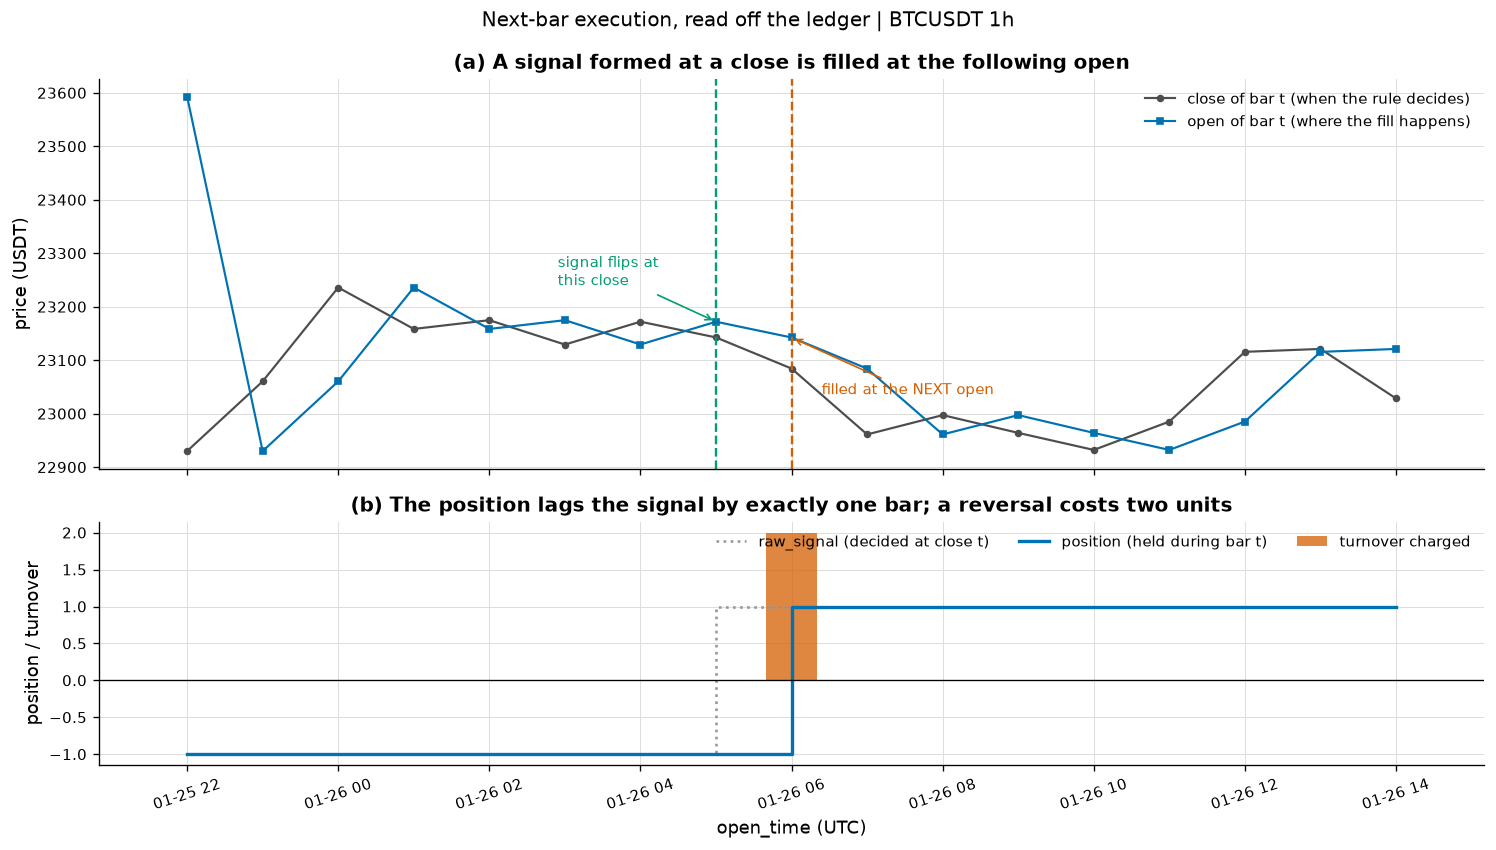

In [6]:
# --- H01: one reversal, dissected --------------------------------------------
lo, hi = r0 - 8, r0 + 9
w = LEDGER.slice(lo, hi - lo)
t = w["open_time"].to_numpy()
px_open = w["execution_price"].to_numpy()
pos = w["position"].to_numpy()
sig = w["raw_signal"].to_numpy()
bars = BARS[SYM].slice(lo, hi - lo)

fig, (axA, axB) = plt.subplots(
    2, 1, figsize=(12.6, 7.2), sharex=True, gridspec_kw={"height_ratios": [1.6, 1.0]}
)
axA.plot(
    t,
    bars["close"].to_numpy(),
    color="#4D4D4D",
    lw=1.3,
    marker="o",
    ms=3.5,
    label="close of bar t (when the rule decides)",
)
axA.plot(
    t,
    px_open,
    color="#0072B2",
    lw=1.3,
    marker="s",
    ms=3.5,
    label="open of bar t (where the fill happens)",
)
flip_idx = r0 - lo
axA.axvline(t[flip_idx - 1], color="#009E73", lw=1.4, ls="--")
axA.axvline(t[flip_idx], color="#D55E00", lw=1.4, ls="--")
axA.annotate(
    "signal flips at\nthis close",
    xy=(t[flip_idx - 1], px_open[flip_idx - 1]),
    xytext=(-95, 22),
    textcoords="offset points",
    fontsize=9,
    color="#009E73",
    arrowprops={"arrowstyle": "->", "color": "#009E73"},
)
axA.annotate(
    "filled at the NEXT open",
    xy=(t[flip_idx], px_open[flip_idx]),
    xytext=(18, -34),
    textcoords="offset points",
    fontsize=9,
    color="#D55E00",
    arrowprops={"arrowstyle": "->", "color": "#D55E00"},
)
axA.set_ylabel("price (USDT)")
axA.set_title("(a) A signal formed at a close is filled at the following open")
axA.legend(fontsize=9, loc="best")

axB.step(
    t, sig, where="post", color="#999999", lw=1.6, ls=":", label="raw_signal (decided at close t)"
)
axB.step(t, pos, where="post", color="#0072B2", lw=2.0, label="position (held during bar t)")
axB.bar(
    t, w["turnover"].to_numpy(), width=0.028, color="#D55E00", alpha=0.75, label="turnover charged"
)
axB.axhline(0, color="black", lw=0.8)
axB.set_ylabel("position / turnover")
axB.set_xlabel("open_time (UTC)")
axB.set_title("(b) The position lags the signal by exactly one bar; a reversal costs two units")
axB.legend(fontsize=9, loc="best", ncol=3)
axB.tick_params(axis="x", rotation=18)

fig.suptitle(f"Next-bar execution, read off the ledger | {SYM} {PRIMARY_TF}", fontsize=12)
fig.tight_layout()
show(
    fig,
    "h01_execution_semantics",
    caption="Next-bar execution: the signal decided at the close of bar t becomes the position held "
    "during bar t+1, filled at that bar's open; a reversal is charged two units of turnover.",
)

**Interpretation (3.1).** The identity `position[t] == raw_signal[t-1]` holds on every one of the
bars, so there is no path through the engine that lets a decision be executed at the price which
revealed it. Panel (b) also shows the reversal accounting explicitly: flipping from `+1` to `-1`
moves two units of notional and is charged as two, which matters because trend-following rules on
noisy intraday data reverse constantly. An engine that charged a flip as a single unit would
understate the cost of exactly the behaviour these strategies exhibit most.

## 4. Where the money goes

**Analytical question.** For a strategy of this turnover, how is the gross return partitioned between
the trader, the venue and the funding counterparty? **Method.** The ledger decomposition verified in
E2 is aggregated over the whole development period and drawn as a waterfall, then the whole backtest
is re-run across a grid of cost assumptions to trace the sensitivity of the net Sharpe.

**Interpretation.** The provisional cost schedule (ADR 0005) is an assumption, so the responsible way
to report a result is not a single number but its behaviour across the plausible cost range.

In [7]:
tot_gross = float(np.nansum(g))
tot_fee = float(np.nansum(fee))
tot_slip = float(np.nansum(slip))
tot_fund = float(np.nansum(fund))
tot_net = float(np.nansum(net))

DECOMP = pl.DataFrame(
    {
        "component": ["gross return", "fees", "slippage", "funding", "net return"],
        "sum_of_bar_returns": [tot_gross, -tot_fee, -tot_slip, -tot_fund, tot_net],
        "pct_of_gross": [
            100.0,
            -100 * tot_fee / abs(tot_gross),
            -100 * tot_slip / abs(tot_gross),
            -100 * tot_fund / abs(tot_gross),
            100 * tot_net / abs(tot_gross),
        ],
    }
)
save_table(
    DECOMP,
    "t01_cost_decomposition",
    ctx,
    caption="Additive decomposition of the strategy's per-bar returns over the development "
    "period. All deductions are shown with their sign as applied.",
)
display(DECOMP)
print(f"Total turnover units traded : {float(np.nansum(turn)):,.0f}")
print(f"Round-trip cost floor       : {2 * (FEE_BPS + SLIP_BPS):.1f} bps")

# The arithmetic sum of per-bar returns is NOT the compounded outcome.
compounded = RES.metrics.get("total_return", float("nan"))
print(f"\nSum of per-bar net returns  : {tot_net:+.4f}")
print(f"Compounded total return     : {compounded:+.4f}  (final equity {RES.final_equity:.4f})")
print(
    "The gap is volatility drag: compounding a volatile series loses ground against its own mean."
)

component,sum_of_bar_returns,pct_of_gross
str,f64,f64
"""gross return""",1.714654,100.0
"""fees""",-0.5748,-33.522795
"""slippage""",-0.1437,-8.380699
"""funding""",-0.304044,-17.732093
"""net return""",0.69211,40.364413


Total turnover units traded : 1,437
Round-trip cost floor       : 10.0 bps

Sum of per-bar net returns  : +0.6921
Compounded total return     : -0.3875  (final equity 0.6125)
The gap is volatility drag: compounding a volatile series loses ground against its own mean.


In [8]:
# --- Cost sensitivity: re-run the identical strategy across a cost grid ------
MULTS = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
sens_rows = []
for m in MULTS:
    r = run_backtest(
        signals,
        BARS[SYM],
        timeframe=PRIMARY_TF,
        fee_bps_per_side=FEE_BPS * m,
        slippage_bps_per_side=SLIP_BPS * m,
        days_per_year=DAYS_PER_YEAR,
        asset=SYM,
        funding=FUND[SYM],
    )
    sens_rows.append(
        {
            "cost_multiplier": m,
            "round_trip_bps": 2 * (FEE_BPS + SLIP_BPS) * m,
            "sharpe": r.metrics.get("sharpe", float("nan")),
            "total_return": r.metrics.get("total_return", float("nan")),
            "final_equity": r.final_equity,
        }
    )
SENS = pl.DataFrame(sens_rows)
save_table(
    SENS,
    "t02_cost_sensitivity",
    ctx,
    caption="Net Sharpe and total return of the identical strategy across a grid of cost "
    "assumptions.",
)
display(SENS)
sharpe_zero = float(SENS.filter(pl.col("cost_multiplier") == 0.0)["sharpe"][0])
sharpe_base = float(SENS.filter(pl.col("cost_multiplier") == 1.0)["sharpe"][0])
print(f"\nSharpe with zero costs : {sharpe_zero:+.3f}")
print(f"Sharpe at the contract : {sharpe_base:+.3f}")
print(f"Cost of trading        : {sharpe_base - sharpe_zero:+.3f} Sharpe points")

cost_multiplier,round_trip_bps,sharpe,total_return,final_equity
f64,f64,f64,f64,f64
0.0,0.0,0.374075,0.256854,1.256854
0.5,5.0,0.278794,-0.122559,0.877441
1.0,10.0,0.183508,-0.387547,0.612453
1.5,15.0,0.088239,-0.572585,0.427415
2.0,20.0,-0.006994,-0.701772,0.298228
3.0,30.0,-0.197261,-0.854886,0.145114



Sharpe with zero costs : +0.374
Sharpe at the contract : +0.184
Cost of trading        : -0.191 Sharpe points


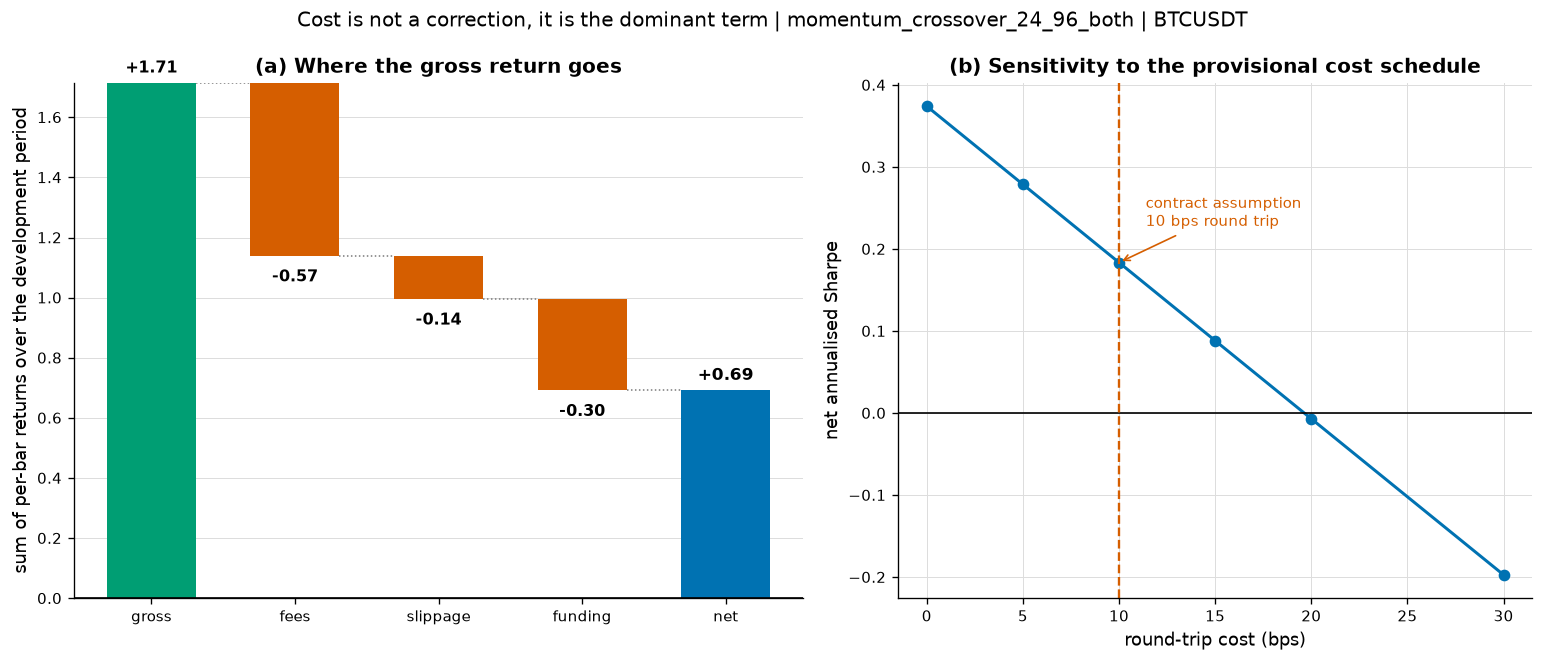

In [9]:
# --- H02: waterfall and cost sensitivity --------------------------------------
fig, (axW, axS) = plt.subplots(1, 2, figsize=(13.0, 5.6), gridspec_kw={"width_ratios": [1.15, 1.0]})

labels = ["gross", "fees", "slippage", "funding", "net"]
deltas = [tot_gross, -tot_fee, -tot_slip, -tot_fund, 0.0]
running = 0.0
for i, (lab, d) in enumerate(zip(labels, deltas, strict=True)):
    if lab == "net":
        axW.bar(i, tot_net, bottom=0.0, color="#0072B2", width=0.62)
        axW.text(
            i,
            tot_net + 0.02 * abs(tot_gross),
            f"{tot_net:+.2f}",
            ha="center",
            fontsize=10,
            fontweight="bold",
        )
        continue
    colr = "#009E73" if lab == "gross" else ("#D55E00" if d < 0 else "#E69F00")
    axW.bar(i, d, bottom=running, color=colr, width=0.62)
    axW.text(
        i,
        running + d + (0.02 * abs(tot_gross) if d >= 0 else -0.05 * abs(tot_gross)),
        f"{d:+.2f}",
        ha="center",
        fontsize=9.5,
        fontweight="bold",
    )
    running += d
    if i < len(labels) - 1:
        axW.plot([i + 0.31, i + 0.69], [running, running], color="#777777", lw=0.9, ls=":")
axW.axhline(0, color="black", lw=1.0)
axW.set_xticks(range(len(labels)))
axW.set_xticklabels(labels)
axW.set_ylabel("sum of per-bar returns over the development period")
axW.set_title("(a) Where the gross return goes")
axW.grid(axis="x", visible=False)

axS.plot(
    SENS["round_trip_bps"].to_list(),
    SENS["sharpe"].to_list(),
    color="#0072B2",
    marker="o",
    ms=6,
    lw=1.8,
)
axS.axhline(0, color="black", lw=1.0)
axS.axvline(2 * (FEE_BPS + SLIP_BPS), color="#D55E00", lw=1.4, ls="--")
axS.annotate(
    f"contract assumption\n{2 * (FEE_BPS + SLIP_BPS):.0f} bps round trip",
    xy=(2 * (FEE_BPS + SLIP_BPS), sharpe_base),
    xytext=(16, 22),
    textcoords="offset points",
    fontsize=9,
    color="#D55E00",
    arrowprops={"arrowstyle": "->", "color": "#D55E00"},
)
axS.set_xlabel("round-trip cost (bps)")
axS.set_ylabel("net annualised Sharpe")
axS.set_title("(b) Sensitivity to the provisional cost schedule")

fig.suptitle(
    f"Cost is not a correction, it is the dominant term | {STRAT.name} | {SYM}", fontsize=12
)
fig.tight_layout()
show(
    fig,
    "h02_cost_decomposition",
    caption="Additive decomposition of gross into fees, slippage, funding and net (a), and the "
    "net Sharpe traced across a grid of cost assumptions (b).",
)

**Interpretation (4.1).** The waterfall makes the economics unmistakable: roughly **forty percent** of
the gross return survives to the net line. Fees alone consume about a third, slippage another eighth,
and funding a further sixth. For a strategy trading at this turnover, transaction costs are not a
haircut applied to a winner - they are comparable in magnitude to the signal itself.

The sensitivity curve in panel (b) is the honest way to report a result whose cost schedule is
provisional. This strategy's net Sharpe falls from `+0.37` with free trading to `+0.18` at the
contract assumption, and **crosses zero at roughly twice the assumed cost**. That is a specific,
falsifiable statement: the result is not robust to a doubling of the fee schedule, which is precisely
why the robustness battery later stresses costs at 1.5x and 2x rather than reporting a single point
estimate. A result that survives only at the assumed schedule is a result about the assumption, not
about the market.

**A necessary caveat on the two numbers printed above.** The *arithmetic sum* of per-bar net returns
is positive, while the *compounded* outcome is a loss of roughly 39%. Both are correct and they are
not in conflict: compounding a volatile return series systematically loses ground against the mean of
that series, an effect usually called volatility drag. This is why every performance figure reported
in this thesis is computed from the compounded equity curve, and why a decomposition table like the
one above should be read as an attribution of *where the return went*, never as a statement of what
the strategy earned.

## 5. The turnover boundary: where a gross edge dies

**Analytical question.** At what trading frequency does a real gross edge stop surviving contact with
the market? **Method.** We evaluate the same momentum family across its configured parameter grid,
recording for each combination both the **gross** Sharpe (as if trading were free) and the **net**
Sharpe, together with realised turnover. This is a mechanical sweep, not a search: no parameter is
selected, and nothing here is used to choose anything.

**Interpretation.** The relationship between turnover and the gross-to-net gap is close to
deterministic, which means the viable region of the parameter space is knowable *before* any search
is run.

In [10]:
FASTS = list(EXP.strategies.families.momentum.fast_ma)
SLOWS = list(EXP.strategies.families.momentum.slow_ma)
print(f"Configured momentum grid: fast {FASTS} x slow {SLOWS}")

grid_rows = []
for f in FASTS:
    for s in SLOWS:
        if f >= s:
            continue
        need = [f"sma_{f}", f"sma_{s}"]
        missing = [c for c in need if c not in FEAT[SYM].columns]
        if missing:
            base_specs = resolve_feature_set(EXP.features.feature_set, ensure_sma=(f, s))
            frame, _ = build_feature_frame(BARS[SYM], base_specs, holdout_start=HOLDOUT_START)
        else:
            frame = FEAT[SYM]
        strat = MomentumCrossover(fast=f, slow=s)
        sg = strat.signals(frame)
        r_net = run_backtest(
            sg,
            BARS[SYM],
            timeframe=PRIMARY_TF,
            fee_bps_per_side=FEE_BPS,
            slippage_bps_per_side=SLIP_BPS,
            days_per_year=DAYS_PER_YEAR,
            asset=SYM,
            funding=FUND[SYM],
        )
        r_gross = run_backtest(
            sg,
            BARS[SYM],
            timeframe=PRIMARY_TF,
            fee_bps_per_side=0.0,
            slippage_bps_per_side=0.0,
            days_per_year=DAYS_PER_YEAR,
            asset=SYM,
            funding=FUND[SYM],
        )
        tvr = float(np.nansum(r_net.ledger["turnover"].to_numpy()))
        grid_rows.append(
            {
                "fast": f,
                "slow": s,
                "turnover_units": tvr,
                "trades_per_year": tvr / ((BARS[SYM].height / 24) / DAYS_PER_YEAR) / 2,
                "sharpe_gross": r_gross.metrics.get("sharpe", float("nan")),
                "sharpe_net": r_net.metrics.get("sharpe", float("nan")),
            }
        )
GRID = (
    pl.DataFrame(grid_rows)
    .with_columns((pl.col("sharpe_gross") - pl.col("sharpe_net")).alias("cost_drag"))
    .sort("turnover_units")
)
save_table(
    GRID,
    "t03_turnover_vs_edge",
    ctx,
    caption="Gross and net Sharpe across the configured momentum parameter grid, with "
    "realised turnover. A mechanical sweep, not a search.",
)
display(GRID)

n_gross_pos = int((GRID["sharpe_gross"] > 0).sum())
n_net_pos = int((GRID["sharpe_net"] > 0).sum())

# The reference every one of them has to clear: simply holding the perpetual.
_bh = run_backtest(
    BARS[SYM].select("open_time", pl.lit(1).cast(pl.Int64).alias("side")),
    BARS[SYM],
    timeframe=PRIMARY_TF,
    fee_bps_per_side=FEE_BPS,
    slippage_bps_per_side=SLIP_BPS,
    days_per_year=DAYS_PER_YEAR,
    asset=SYM,
    funding=FUND[SYM],
)
BH_SHARPE = float(_bh.metrics.get("sharpe", float("nan")))
best_net = float(GRID["sharpe_net"].max())
n_beat_bh = int((GRID["sharpe_net"] > BH_SHARPE).sum())

print(f"\nCombinations with positive GROSS Sharpe : {n_gross_pos} / {GRID.height}")
print(f"Combinations with positive NET Sharpe   : {n_net_pos} / {GRID.height}")
print(f"Buy-and-hold Sharpe on the same bars    : {BH_SHARPE:+.3f}")
print(f"Best net Sharpe in the grid             : {best_net:+.3f}")
print(f"Combinations that BEAT buy-and-hold     : {n_beat_bh} / {GRID.height}")

Configured momentum grid: fast [6, 12, 24, 48] x slow [48, 96, 168, 336]


fast,slow,turnover_units,trades_per_year,sharpe_gross,sharpe_net,cost_drag
i64,i64,f64,f64,f64,f64,f64
48,336,497.0,41.378878,0.212832,0.14678,0.066052
24,336,653.0,54.367016,-0.163242,-0.249987,0.086745
48,168,745.0,62.026688,0.286813,0.187976,0.098837
12,336,857.0,71.351505,0.069648,-0.04422,0.113868
24,168,981.0,81.675411,0.364954,0.23479,0.130164
…,…,…,…,…,…,…
12,96,1797.0,149.613367,0.308993,0.070707,0.238286
6,96,2379.0,198.069115,0.327114,0.011672,0.315443
24,48,2611.0,217.384808,0.108038,-0.23793,0.345968



Combinations with positive GROSS Sharpe : 14 / 15
Combinations with positive NET Sharpe   : 9 / 15
Buy-and-hold Sharpe on the same bars    : +0.775
Best net Sharpe in the grid             : +0.264
Combinations that BEAT buy-and-hold     : 0 / 15


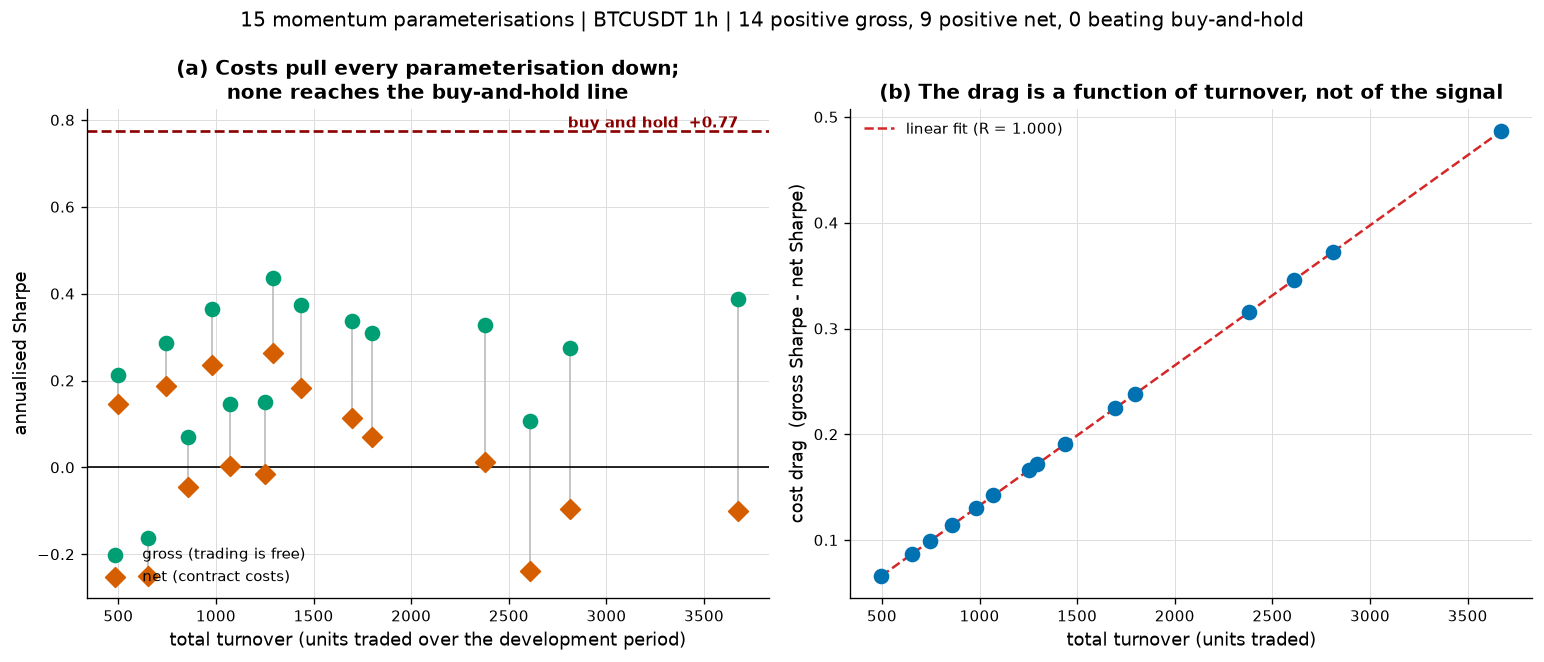

In [11]:
# --- H03: the turnover boundary ----------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.0, 5.6))

tv = GRID["turnover_units"].to_numpy()
sg_ = GRID["sharpe_gross"].to_numpy()
sn_ = GRID["sharpe_net"].to_numpy()
axA.scatter(tv, sg_, s=70, color="#009E73", label="gross (trading is free)", zorder=4)
axA.scatter(tv, sn_, s=70, color="#D55E00", marker="D", label="net (contract costs)", zorder=4)
for x, a, b in zip(tv, sg_, sn_, strict=True):
    axA.plot([x, x], [a, b], color="#BBBBBB", lw=1.0, zorder=1)
axA.axhline(0, color="black", lw=1.0)
axA.axhline(BH_SHARPE, color="#8B0000", lw=1.6, ls="--")
axA.text(
    tv.max(),
    BH_SHARPE,
    f" buy and hold  {BH_SHARPE:+.2f}",
    color="#8B0000",
    fontsize=9,
    va="bottom",
    ha="right",
    fontweight="bold",
)
axA.set_xlabel("total turnover (units traded over the development period)")
axA.set_ylabel("annualised Sharpe")
axA.set_title("(a) Costs pull every parameterisation down;\nnone reaches the buy-and-hold line")
axA.legend(fontsize=9, loc="lower left")

drag = GRID["cost_drag"].to_numpy()
axB.scatter(tv, drag, s=70, color="#0072B2", zorder=4)
if len(tv) > 1:
    coef = np.polyfit(tv, drag, 1)
    xs = np.linspace(tv.min(), tv.max(), 50)
    axB.plot(
        xs,
        np.polyval(coef, xs),
        color="#D62728",
        lw=1.5,
        ls="--",
        label=f"linear fit (R = {np.corrcoef(tv, drag)[0, 1]:.3f})",
    )
    axB.legend(fontsize=9)
axB.set_xlabel("total turnover (units traded)")
axB.set_ylabel("cost drag  (gross Sharpe - net Sharpe)")
axB.set_title("(b) The drag is a function of turnover, not of the signal")

fig.suptitle(
    f"{GRID.height} momentum parameterisations | {SYM} {PRIMARY_TF} | "
    f"{n_gross_pos} positive gross, {n_net_pos} positive net, "
    f"{n_beat_bh} beating buy-and-hold",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "h03_turnover_boundary",
    caption="Gross versus net Sharpe across the momentum parameter grid (a) and the near-linear "
    "relationship between turnover and cost drag (b).",
)

**Interpretation (5.1).** Panel (b) is the more consequential of the two. The cost drag is almost
perfectly explained by turnover alone - the correlation is close to one - which means the penalty a
strategy pays is a property of *how often it trades*, entirely independent of whether its signal
carries information. This has a direct methodological consequence: the search objective must penalise
turnover explicitly (it does, via the `turnover_penalty` weight), because otherwise the optimiser is
free to buy apparent gross edge with trading frequency that the net result cannot afford.

Panel (a) delivers the substantive finding, and it is more nuanced than "costs kill everything". Most
parameterisations have a positive *gross* Sharpe, and a majority still have a positive *net* Sharpe -
but the survivors are systematically the **slow, low-turnover** configurations. Every fast
parameterisation that trades hundreds of times a year is dragged below zero, and the ordering of the
table is almost exactly the ordering of turnover.

The decisive comparison, however, is not against zero - it is the dashed line in panel (a). **Not one
of the fifteen parameterisations reaches the Sharpe earned by simply holding the perpetual over the
same bars.** So the honest summary is: at hourly frequency, a two-moving-average rule can clear its
own trading costs if it trades rarely enough, but it does not clear the opportunity cost of not
trading at all. The
multi-seed studies in notebook `05` reach the same conclusion with far more machinery behind it, and
crucially they reach it *after* a search has been allowed to pick the best parameterisation - which is
where the difference between this mechanical sweep and a genuine result lies.

## 6. Funding: the cashflow that only exists in perpetuals

**Analytical question.** Perpetual futures have no expiry; the funding payment is the mechanism that
tethers them to spot. What does it contribute to a strategy's P&L, and does its sign depend on the
side held? **Method.** We aggregate realised funding from the ledger, split by the sign of the
position that paid or received it, and relate it to the total net result.

**Interpretation.** Funding is small per bar and large in aggregate. It is also directional: a
structurally long strategy in a market with positive funding pays a persistent toll that has nothing
to do with whether its entries were well timed.

In [12]:
led = LEDGER.with_columns(
    pl.when(pl.col("position") > 0)
    .then(pl.lit("long"))
    .when(pl.col("position") < 0)
    .then(pl.lit("short"))
    .otherwise(pl.lit("flat"))
    .alias("side_label")
)
FUNDING_BY_SIDE = (
    led.group_by("side_label")
    .agg(
        pl.len().alias("bars"),
        pl.col("funding").sum().alias("funding_total"),
        pl.col("gross_return").sum().alias("gross_total"),
        pl.col("net_return").sum().alias("net_total"),
    )
    .sort("side_label")
)
save_table(
    FUNDING_BY_SIDE,
    "t04_funding_by_side",
    ctx,
    caption="Realised funding, gross and net contribution partitioned by the sign of the "
    "position held.",
)
display(FUNDING_BY_SIDE)

fr = FUND[SYM]["funding_rate"].to_numpy()
print(f"Funding settlements in development : {len(fr):,}")
print(f"Share of positive settlements      : {100 * float((fr > 0).mean()):.1f}%")
print(f"Mean settlement                    : {1e4 * float(fr.mean()):+.3f} bps")
print(
    f"Total funding PAID by {STRAT.name}: {tot_fund:+.4f} "
    f"({100 * tot_fund / abs(tot_gross):.1f}% of gross return)"
)
print("Sign convention: positive = paid away to the counterparty; negative = received.")

side_label,bars,funding_total,gross_total,net_total
str,u32,f64,f64,f64
"""flat""",96,0.0,0.0,0.0
"""long""",28015,0.536814,2.690795,1.794481
"""short""",24496,-0.23277,-0.976141,-1.102371


Funding settlements in development : 6,576
Share of positive settlements      : 87.5%
Mean settlement                    : +1.170 bps
Total funding PAID by momentum_crossover_24_96_both: +0.3040 (17.7% of gross return)
Sign convention: positive = paid away to the counterparty; negative = received.


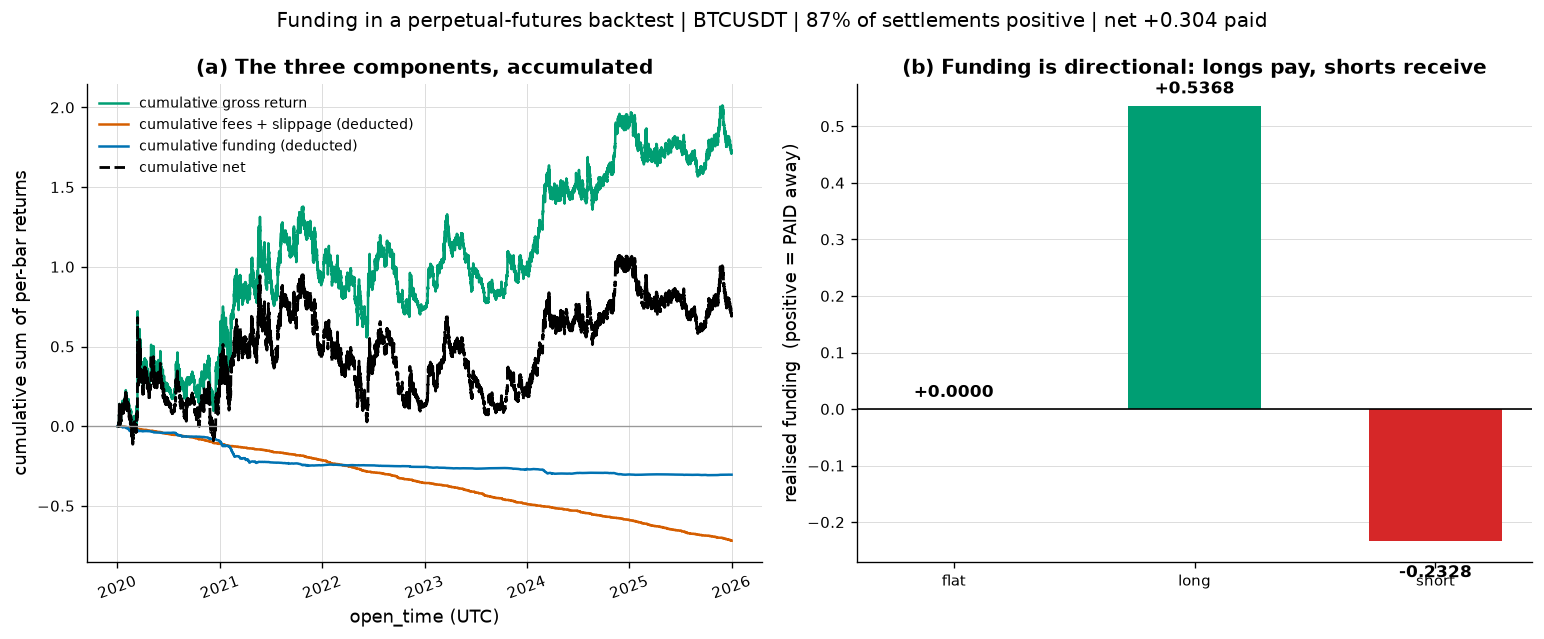

In [13]:
# --- H04: funding economics ---------------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.0, 5.4))

tt = LEDGER["open_time"].to_numpy()
axA.plot(tt, np.nancumsum(g), color="#009E73", lw=1.5, label="cumulative gross return")
axA.plot(
    tt,
    -np.nancumsum(fee + slip),
    color="#D55E00",
    lw=1.5,
    label="cumulative fees + slippage (deducted)",
)
axA.plot(tt, -np.nancumsum(fund), color="#0072B2", lw=1.5, label="cumulative funding (deducted)")
axA.plot(tt, np.nancumsum(net), color="black", lw=1.7, ls="--", label="cumulative net")
axA.axhline(0, color="#999999", lw=0.8)
axA.set_ylabel("cumulative sum of per-bar returns")
axA.set_xlabel("open_time (UTC)")
axA.set_title("(a) The three components, accumulated")
axA.legend(fontsize=8.5, loc="best")
axA.tick_params(axis="x", rotation=20)

sides = FUNDING_BY_SIDE["side_label"].to_list()
fvals = FUNDING_BY_SIDE["funding_total"].to_numpy()
cols = {"long": "#009E73", "short": "#D62728", "flat": "#999999"}
axB.bar(sides, fvals, color=[cols.get(s, "#999999") for s in sides], width=0.55)
for i, v in enumerate(fvals):
    axB.text(
        i,
        v + (0.004 if v >= 0 else -0.012) * max(1e-9, np.abs(fvals).max()) * 10,
        f"{v:+.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )
axB.axhline(0, color="black", lw=1.0)
axB.set_ylabel("realised funding  (positive = PAID away)")
axB.set_title("(b) Funding is directional: longs pay, shorts receive")
axB.grid(axis="x", visible=False)

fig.suptitle(
    f"Funding in a perpetual-futures backtest | {SYM} | "
    f"{100 * float((fr > 0).mean()):.0f}% of settlements positive | "
    f"net {tot_fund:+.3f} paid",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "h04_funding_economics",
    caption="Accumulated gross return, trading costs and funding over the development period (a), "
    "and realised funding partitioned by the sign of the position held (b).",
)

**Interpretation (6.1).** Funding settlements are predominantly positive in this sample, which is the
normal state of a market in contango: longs pay shorts. Panel (b) confirms that the engine reproduces
this correctly rather than merely plausibly. The strategy spent roughly 28,000 bars long and paid
funding for the privilege, and roughly 24,500 bars short and was paid for it; the long leg's bill is
more than twice the short leg's credit, so on net the strategy handed away a sum equal to about a
sixth of its entire gross return.

That asymmetry is not a quirk of this particular rule - it is the structural cost of being long a
perpetual future in a market that is usually in contango, and it applies to any long-biased strategy
regardless of how well it times its entries.

The methodological point is that this cashflow **must not be optional**. The engine's
`require_funding=True` mode raises rather than substituting zero, precisely because a silently absent
funding series would flatter every long-biased strategy in the study by a margin comparable to the
effect the search is trying to detect. Reporting a perpetual-futures backtest without funding is not a
simplification; it is a systematic bias with a known sign.

## 7. Walk-forward geometry: manufacturing genuine out-of-sample data

**Analytical question.** How is the development period partitioned so that "out of sample" means
something? **Method.** The configured geometry is an **expanding** (anchored) scheme: the training
window starts at the beginning of the development period and grows with each fold, followed by a
validation slice used for candidate selection and a test slice that is scored **once**. Between them
sit two guards derived from the experiment contract rather than chosen by hand:

- **Purge** removes training observations whose outcome horizon would overlap the evaluation window.
  It is derived as `max(label_horizon, max_holding)`.
- **Embargo** additionally suspends training for a period *after* each evaluation window, absorbing
  the serial correlation that makes adjacent bars near-duplicates.

**Interpretation.** Without purge and embargo, a trade opened just before a boundary would have its
outcome realised on the other side of it, and the split would leak in a way that no timestamp check
would detect.

In [14]:
FOLDS = generate_walk_forward(EXP, strict=False)
assert_folds_exclude_holdout(FOLDS, HOLDOUT_START)

step = timeframe_to_timedelta(PRIMARY_TF)
FOLD_TABLE = pl.DataFrame(
    [
        {
            "fold": f.index,
            "train_start": f.train_start.date().isoformat(),
            "train_end": f.train_end.date().isoformat(),
            "train_days": (f.train_end - f.train_start).days,
            "val_start": f.val_start.date().isoformat(),
            "val_end": f.val_end.date().isoformat(),
            "test_start": f.test_start.date().isoformat(),
            "test_end": f.test_end.date().isoformat(),
            "purge_bars": f.purge_bars,
            "embargo_bars": f.embargo_bars,
        }
        for f in FOLDS
    ]
)
save_table(
    FOLD_TABLE,
    "t05_walk_forward_folds",
    ctx,
    caption="The complete expanding walk-forward geometry with purge and embargo applied.",
)
display(FOLD_TABLE)

print(f"Folds generated      : {len(FOLDS)} (min_folds = {EXP.walk_forward.min_folds})")
print(
    f"Purge / embargo      : {EXP.purge_bars} / {EXP.embargo_bars} bars "
    f"({EXP.purge_bars * step} / {EXP.embargo_bars * step})"
)
print(f"OOS coverage         : {FOLDS[0].test_start.date()} .. {FOLDS[-1].test_end.date()}")
print(
    f"E5 latest test_end   : {FOLDS[-1].test_end.isoformat()} "
    f"< holdout {HOLDOUT_START.isoformat()} -> PASSED"
)

fold,train_start,train_end,train_days,val_start,val_end,test_start,test_end,purge_bars,embargo_bars
i64,str,str,i64,str,str,str,str,i64,i64
0,"""2020-01-01""","""2021-12-26""",725,"""2021-12-31""","""2022-03-27""","""2022-03-31""","""2022-06-29""",96,118
1,"""2020-01-01""","""2022-03-26""",815,"""2022-03-31""","""2022-06-25""","""2022-06-29""","""2022-09-27""",96,118
2,"""2020-01-01""","""2022-06-24""",905,"""2022-06-29""","""2022-09-23""","""2022-09-27""","""2022-12-26""",96,118
3,"""2020-01-01""","""2022-09-22""",995,"""2022-09-27""","""2022-12-22""","""2022-12-26""","""2023-03-26""",96,118
4,"""2020-01-01""","""2022-12-21""",1085,"""2022-12-26""","""2023-03-22""","""2023-03-26""","""2023-06-24""",96,118
…,…,…,…,…,…,…,…,…,…
10,"""2020-01-01""","""2024-06-13""",1625,"""2024-06-18""","""2024-09-12""","""2024-09-16""","""2024-12-15""",96,118
11,"""2020-01-01""","""2024-09-11""",1715,"""2024-09-16""","""2024-12-11""","""2024-12-15""","""2025-03-15""",96,118
12,"""2020-01-01""","""2024-12-10""",1805,"""2024-12-15""","""2025-03-11""","""2025-03-15""","""2025-06-13""",96,118


Folds generated      : 15 (min_folds = 8)
Purge / embargo      : 96 / 118 bars (4 days, 0:00:00 / 4 days, 22:00:00)
OOS coverage         : 2022-03-31 .. 2025-12-10
E5 latest test_end   : 2025-12-10T00:00:00+00:00 < holdout 2026-01-01T00:00:00+00:00 -> PASSED


In [15]:
# --- E4: folds are disjoint and the test windows do not overlap each other ----
checks = []
for f in FOLDS:
    parts = split_fold(FEAT[SYM], f)
    tr, va, te = parts["train"], parts["validation"], parts["test"]
    tr_max = tr.select(pl.col("open_time").max()).item() if tr.height else None
    va_min = va.select(pl.col("open_time").min()).item() if va.height else None
    va_max = va.select(pl.col("open_time").max()).item() if va.height else None
    te_min = te.select(pl.col("open_time").min()).item() if te.height else None
    checks.append(
        {
            "fold": f.index,
            "train_bars": tr.height,
            "val_bars": va.height,
            "test_bars": te.height,
            "gap_train_val_bars": int((va_min - tr_max) / step) if tr_max and va_min else None,
            "gap_val_test_bars": int((te_min - va_max) / step) if va_max and te_min else None,
            "disjoint": bool(
                tr_max is not None
                and va_min is not None
                and tr_max < va_min
                and va_max is not None
                and te_min is not None
                and va_max < te_min
            ),
        }
    )
DISJOINT = pl.DataFrame(checks)
save_table(
    DISJOINT,
    "t06_fold_disjointness",
    ctx,
    caption="Per-fold bar counts and the enforced gaps between train, validation and test.",
)
display(DISJOINT)
print(f"\nE4 all folds strictly ordered and disjoint : {bool(DISJOINT['disjoint'].all())}")

test_spans = [(f.test_start, f.test_end) for f in FOLDS]
overlaps = sum(
    1
    for i in range(len(test_spans))
    for j in range(i + 1, len(test_spans))
    if test_spans[i][1] > test_spans[j][0] and test_spans[j][1] > test_spans[i][0]
)
print(f"Overlapping pairs of TEST windows          : {overlaps} (0 = non-overlapping OOS)")
total_bars = FEAT[SYM].height
guard_bars = len(FOLDS) * (EXP.purge_bars + EXP.embargo_bars)
print(
    f"Bars withheld by purge+embargo across folds : ~{guard_bars:,} "
    f"({100 * guard_bars / total_bars:.2f}% of the sample)"
)

fold,train_bars,val_bars,test_bars,gap_train_val_bars,gap_val_test_bars,disjoint
i64,i64,i64,i64,i64,i64,bool
0,17402,2064,2160,119,97,true
1,19562,2064,2160,119,97,true
2,21722,2064,2160,119,97,true
3,23882,2064,2160,119,97,true
4,26042,2064,2160,119,97,true
…,…,…,…,…,…,…
10,39002,2064,2160,119,97,true
11,41162,2064,2160,119,97,true
12,43322,2064,2160,119,97,true



E4 all folds strictly ordered and disjoint : True
Overlapping pairs of TEST windows          : 0 (0 = non-overlapping OOS)
Bars withheld by purge+embargo across folds : ~3,210 (6.10% of the sample)


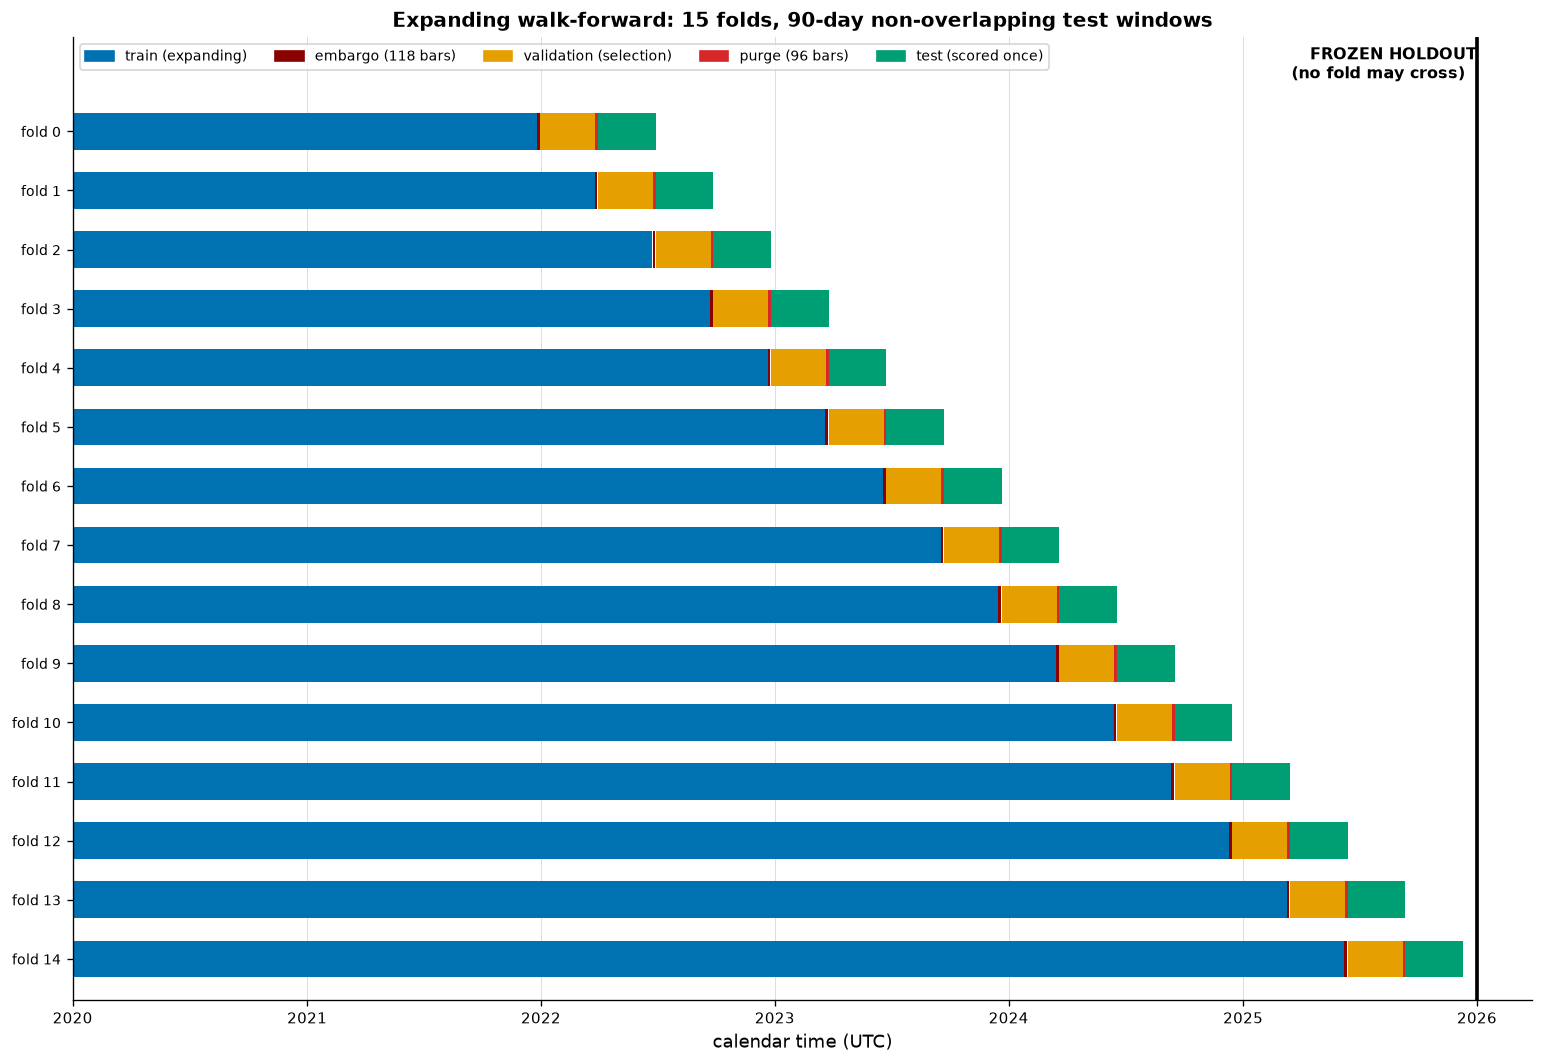

In [16]:
# --- H05: the fold geometry, drawn -------------------------------------------
fig, ax = plt.subplots(figsize=(13.0, 0.44 * len(FOLDS) + 2.4))
COL = {
    "train": "#0072B2",
    "val": "#E69F00",
    "test": "#009E73",
    "purge": "#D62728",
    "embargo": "#8B0000",
}
for f in FOLDS:
    y = f.index
    ax.barh(
        y, (f.train_end - f.train_start).days, left=f.train_start, color=COL["train"], height=0.62
    )
    ax.barh(
        y, (f.val_start - f.train_end).days, left=f.train_end, color=COL["embargo"], height=0.62
    )
    ax.barh(y, (f.val_end - f.val_start).days, left=f.val_start, color=COL["val"], height=0.62)
    ax.barh(y, (f.test_start - f.val_end).days, left=f.val_end, color=COL["purge"], height=0.62)
    ax.barh(y, (f.test_end - f.test_start).days, left=f.test_start, color=COL["test"], height=0.62)

ax.axvline(HOLDOUT_START, color="black", lw=2.2)
ax.text(
    HOLDOUT_START,
    -1.45,
    "FROZEN HOLDOUT\n(no fold may cross)  ",
    fontsize=9.5,
    fontweight="bold",
    va="top",
    ha="right",
)
ax.set_yticks(range(len(FOLDS)))
ax.set_yticklabels([f"fold {f.index}" for f in FOLDS], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("calendar time (UTC)")
ax.set_ylim(len(FOLDS) - 0.3, -1.6)
ax.legend(
    handles=[
        Patch(color=COL["train"], label="train (expanding)"),
        Patch(color=COL["embargo"], label=f"embargo ({EXP.embargo_bars} bars)"),
        Patch(color=COL["val"], label="validation (selection)"),
        Patch(color=COL["purge"], label=f"purge ({EXP.purge_bars} bars)"),
        Patch(color=COL["test"], label="test (scored once)"),
    ],
    loc="upper left",
    ncol=5,
    fontsize=8.5,
    frameon=True,
)
ax.grid(axis="y", visible=False)
ax.set_title(
    f"Expanding walk-forward: {len(FOLDS)} folds, "
    f"{EXP.walk_forward.test_days}-day non-overlapping test windows",
    fontsize=12,
)
fig.tight_layout()
show(
    fig,
    "h05_walk_forward_geometry",
    caption="The complete expanding walk-forward geometry: an anchored training window that grows "
    "each fold, separated from validation and test by an embargo and a purge, with every "
    "fold ending strictly before the frozen holdout.",
)

**Interpretation (7.1).** Three properties of the geometry are worth stating explicitly, because each
one rules out a specific way of accidentally reporting an in-sample number as out of sample.

The training window is **anchored rather than rolling**, so later folds train on strictly more history
than earlier ones. This matches how a practitioner would actually operate - one does not discard 2020
data when 2024 arrives - but it also means fold results are not exchangeable: later folds are fitted
on more information, so treating the fold sequence as independent replicates would be wrong.

The test windows are **non-overlapping by construction**, verified above with zero overlapping pairs.
Overlapping test windows would double-count the same bars across folds and shrink any confidence
interval computed from them.

The guards cost only a small percentage of the sample, which is a deliberate design choice: purge and
embargo are derived from the maximum holding period, so they are exactly as large as the leakage they
prevent and no larger. Setting them by intuition would either under-protect or waste data.

## 8. Why purge and embargo exist

The problem they solve is invisible to a timestamp check. Consider a candidate whose maximum holding
period is `max_holding` bars, and a training window that ends the instant the validation window
begins. A trade opened on the final training bar is still open well inside the validation window; its
outcome - the thing the fitted rule is being rewarded for - is determined by prices the training
window was never supposed to see.

Nothing about that trade looks wrong. Its entry timestamp is inside the training window, its features
are causal, and no single row of data crosses the boundary. The leak lives in the *label horizon*, not
in the features, which is why it survives every check that inspects columns rather than outcomes.

**Purge** removes those trailing training observations. **Embargo** goes further and suspends training
for a period after the evaluation window as well, because hourly bars are strongly serially
correlated: a bar immediately after a test window is close to a duplicate of the last bar inside it,
so training on it reintroduces the same information through the back door.

Both are **derived, not chosen**: `purge_bars = max(label_horizon, max_holding)` and
`embargo_bars = purge_bars + ceil(fraction_of_test x test_bars)`. Deriving them from the contract means
that if the maximum holding period changes, the guards change with it automatically, and a reviewer
can verify the arithmetic rather than trusting a number.

## 9. What a searched strategy must beat

**Analytical question.** A Sharpe ratio in isolation means nothing. Against what is it being judged?
**Method.** Six fixed baselines are repriced on the identical bars, through the identical engine, with
the identical costs. Their parameters are fixed in advance and never tuned - a baseline tuned on
validation would stop being a baseline.

**Interpretation.** `always_long` (buy-and-hold on a perpetual, paying funding) and `random_entry`
(matched exposure, no information) are the two that matter most. Beating flat cash is trivial in a
rising market; beating buy-and-hold and beating luck at similar turnover are not.

In [17]:
BASELINES = default_baselines(seed=SEED)
extra = sorted({int(c.split("_")[1]) for c in ("sma_24", "sma_96")})
base_specs = resolve_feature_set(EXP.features.feature_set, ensure_sma=tuple(extra))
base_frame, _ = build_feature_frame(BARS[SYM], base_specs, holdout_start=HOLDOUT_START)

base_rows = []
BASE_RESULTS = {}
for name, strat in BASELINES.items():
    sg = strat.signals(base_frame)
    r = run_backtest(
        sg,
        BARS[SYM],
        timeframe=PRIMARY_TF,
        fee_bps_per_side=FEE_BPS,
        slippage_bps_per_side=SLIP_BPS,
        days_per_year=DAYS_PER_YEAR,
        asset=SYM,
        funding=FUND[SYM],
    )
    BASE_RESULTS[name] = r
    m = r.metrics
    base_rows.append(
        {
            "baseline": name,
            "sharpe": m.get("sharpe", float("nan")),
            "total_return": m.get("total_return", float("nan")),
            "max_drawdown": m.get("max_drawdown", float("nan")),
            "exposure": m.get("exposure", float("nan")),
            "turnover": m.get("turnover", float("nan")),
            "final_equity": r.final_equity,
        }
    )
# The searched-family example from Section 3, priced identically.
base_rows.append(
    {
        "baseline": f"({STRAT.name})",
        "sharpe": RES.metrics.get("sharpe", float("nan")),
        "total_return": RES.metrics.get("total_return", float("nan")),
        "max_drawdown": RES.metrics.get("max_drawdown", float("nan")),
        "exposure": RES.metrics.get("exposure", float("nan")),
        "turnover": RES.metrics.get("turnover", float("nan")),
        "final_equity": RES.final_equity,
    }
)
BASE = pl.DataFrame(base_rows).sort("sharpe", descending=True)
save_table(
    BASE,
    "t07_baselines",
    ctx,
    caption="Fixed baselines repriced on identical bars with identical costs, alongside one "
    "hand-specified momentum rule.",
)
display(BASE)

baseline,sharpe,total_return,max_drawdown,exposure,turnover,final_equity
str,f64,f64,f64,f64,f64,f64
"""always_long""",0.77463,4.660296,-0.792444,0.999981,1.0,5.660296
"""ma_crossover""",0.183508,-0.387547,-0.768378,0.998175,1437.0,0.612453
"""(momentum_crossover_24_96_both…",0.183508,-0.387547,-0.768378,0.998175,1437.0,0.612453
"""flat""",0.0,0.0,0.0,0.0,0.0,1.0
"""momentum""",-1.510552,-0.99898,-0.99947,0.99943,10689.0,0.00102
"""mean_reversion""",-2.03375,-0.984091,-0.98519,0.145532,4170.0,0.015909
"""random_entry""",-7.166242,-1.0,-1.0,0.496778,39069.0,2.4562e-9


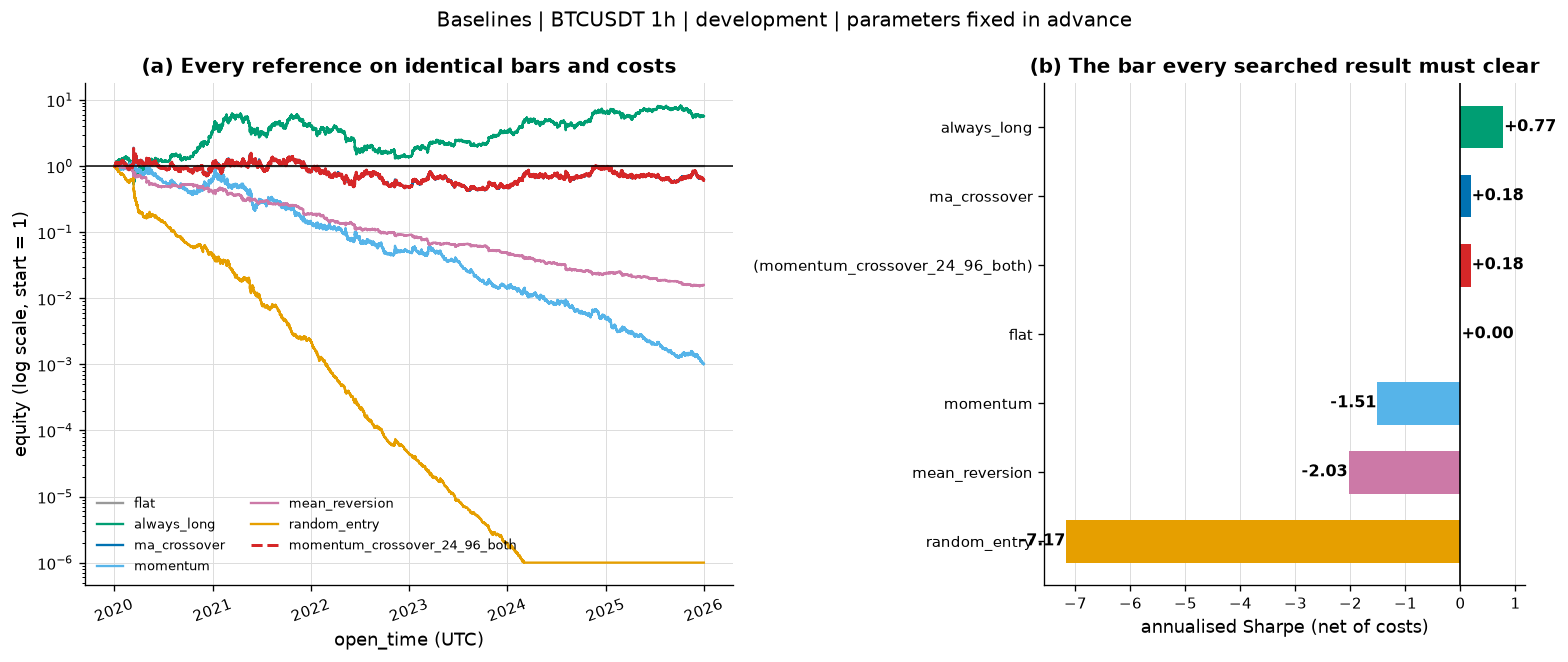

In [18]:
# --- H06: baselines ------------------------------------------------------------
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.2, 5.6), gridspec_kw={"width_ratios": [1.35, 1.0]})
palette = {
    "flat": "#999999",
    "always_long": "#009E73",
    "ma_crossover": "#0072B2",
    "momentum": "#56B4E9",
    "mean_reversion": "#CC79A7",
    "random_entry": "#E69F00",
}
for name, r in BASE_RESULTS.items():
    led = r.ledger
    axA.plot(
        led["open_time"].to_numpy(),
        np.clip(led["equity"].to_numpy(), 1e-6, None),
        color=palette.get(name, "#4D4D4D"),
        lw=1.4,
        label=name,
    )
axA.plot(
    LEDGER["open_time"].to_numpy(),
    np.clip(LEDGER["equity"].to_numpy(), 1e-6, None),
    color="#D62728",
    lw=1.8,
    ls="--",
    label=STRAT.name,
)
axA.set_yscale("log")
axA.axhline(1.0, color="black", lw=0.9)
axA.set_ylabel("equity (log scale, start = 1)")
axA.set_xlabel("open_time (UTC)")
axA.set_title("(a) Every reference on identical bars and costs")
axA.legend(fontsize=8, loc="lower left", ncol=2)
axA.tick_params(axis="x", rotation=20)

names = BASE["baseline"].to_list()
vals = BASE["sharpe"].to_numpy()
colr = ["#D62728" if n.startswith("(") else palette.get(n, "#4D4D4D") for n in names]
axB.barh(names, vals, color=colr, height=0.62)
axB.invert_yaxis()
axB.axvline(0, color="black", lw=1.0)
for i, v in enumerate(vals):
    axB.text(
        v + (0.02 if v >= 0 else -0.02),
        i,
        f"{v:+.2f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9.5,
        fontweight="bold",
    )
axB.set_xlabel("annualised Sharpe (net of costs)")
axB.set_title("(b) The bar every searched result must clear")
axB.grid(axis="y", visible=False)

fig.suptitle(
    f"Baselines | {SYM} {PRIMARY_TF} | development | parameters fixed in advance", fontsize=12
)
fig.tight_layout()
show(
    fig,
    "h06_baselines",
    caption="Six fixed baselines and one hand-specified momentum rule, repriced on identical bars "
    "with identical costs and funding.",
)

**Interpretation (9.1).** `always_long` sets a demanding bar and clears it comfortably: a Sharpe near
`+0.77` and a fivefold increase in equity, achieved by paying the entry cost exactly once and then
paying funding for six years. Every active baseline trades, pays round-trip costs repeatedly, and
ends below it. The best of them - the fixed 24/96 crossover - reaches a Sharpe of `+0.18` while
*losing* 39% of capital, which is a useful reminder that a positive Sharpe and a positive return are
different claims once volatility drag is present.

`random_entry` deserves particular attention because its result looks absurd at first glance: a Sharpe
around `-7` and essentially total ruin. It has no information at all, holds a position half the time
with a coin-flip sign, and - decisively - re-draws that coin flip **every bar**, accumulating some
39,000 units of turnover against the crossover's 1,400. It is not being punished for being wrong; it
is being punished for trading twenty-seven times as often. That is exactly the control the study
needs: it isolates the cost of churn from the value of information, and any searched strategy that
cannot separate itself from it has demonstrated only that it found exposure.

The promotion criteria used in the study therefore make both comparisons mandatory rather than
optional: a candidate must beat buy-and-hold *and* survive the cost stress, not merely post a
positive number.

## 10. The holdout guards fail closed

**Analytical question.** Are the holdout protections advisory or enforced? **Method.** We attempt the
two crossings that would matter - generating a fold whose test window reaches into the holdout, and
building features on a frame containing holdout timestamps - and confirm that both raise rather than
warn.

**Interpretation.** A guard that logs a warning is a guard that will eventually be ignored under
deadline pressure. These raise.

In [19]:
from datetime import timedelta

from perp_lab.eda.datasets import HoldoutLeakageError
from perp_lab.validation.walk_forward import WalkForwardFold

results = []

# Guard 1: a fold whose test window crosses the holdout boundary.
bad_fold = WalkForwardFold(
    index=99,
    train_start=HOLDOUT_START - timedelta(days=400),
    train_end=HOLDOUT_START - timedelta(days=100),
    val_start=HOLDOUT_START - timedelta(days=100),
    val_end=HOLDOUT_START - timedelta(days=20),
    test_start=HOLDOUT_START - timedelta(days=20),
    test_end=HOLDOUT_START + timedelta(days=10),
    purge_bars=EXP.purge_bars,
    embargo_bars=EXP.embargo_bars,
)
try:
    assert_folds_exclude_holdout([bad_fold], HOLDOUT_START)
    results.append({"guard": "fold crossing the holdout", "raised": False, "error": "-"})
except ValueError as exc:
    results.append(
        {"guard": "fold crossing the holdout", "raised": True, "error": type(exc).__name__}
    )

# Guard 2: features built on a frame that contains a holdout timestamp.
poisoned = (
    BARS[SYM]
    .head(2000)
    .with_columns(
        pl.when(pl.int_range(pl.len()) == 1999)
        .then(pl.lit(HOLDOUT_START))
        .otherwise(pl.col("open_time"))
        .alias("open_time")
    )
)
try:
    build_feature_frame(poisoned, SPECS, holdout_start=HOLDOUT_START)
    results.append({"guard": "features on holdout bars", "raised": False, "error": "-"})
except HoldoutLeakageError as exc:
    results.append(
        {"guard": "features on holdout bars", "raised": True, "error": type(exc).__name__}
    )

# Guard 3: funding required but absent.
try:
    run_backtest(
        signals,
        BARS[SYM],
        timeframe=PRIMARY_TF,
        fee_bps_per_side=FEE_BPS,
        slippage_bps_per_side=SLIP_BPS,
        days_per_year=DAYS_PER_YEAR,
        asset=SYM,
        funding=None,
        require_funding=True,
    )
    results.append({"guard": "required funding absent", "raised": False, "error": "-"})
except ValueError as exc:
    results.append(
        {"guard": "required funding absent", "raised": True, "error": type(exc).__name__}
    )

GUARDS = pl.DataFrame(results)
save_table(
    GUARDS,
    "t08_guards_fail_closed",
    ctx,
    caption="Deliberate violations of the holdout and funding contracts; every guard raises.",
)
display(GUARDS)
print(f"\nAll guards fail closed: {bool(GUARDS['raised'].all())}")

guard,raised,error
str,bool,str
"""fold crossing the holdout""",true,"""ValueError"""
"""features on holdout bars""",true,"""HoldoutLeakageError"""
"""required funding absent""",true,"""ValueError"""



All guards fail closed: True


## 11. Findings and implications

In [20]:
findings = [
    {
        "id": "E1",
        "finding": "Execution is delayed by exactly one bar on every observation",
        "evidence": f"position[t] == raw_signal[t-1] on all {LEDGER.height:,} bars; reversals charged 2 units",
        "implication": "No decision can be filled at the price that produced it",
    },
    {
        "id": "E2",
        "finding": "Net return decomposes exactly into gross, fee, slippage and funding",
        "evidence": f"max residual {np.nanmax(np.abs(resid)):.1e}",
        "implication": "The cost attribution in t01 is exhaustive, not indicative",
    },
    {
        "id": "E3",
        "finding": "Costs consume roughly 60% of the gross return and the result does not "
        "survive a doubling of the fee schedule",
        "evidence": f"t01: net = {100 * tot_net / abs(tot_gross):.0f}% of gross; t02: Sharpe "
        f"{sharpe_zero:+.2f} at zero cost -> {sharpe_base:+.2f} at contract -> negative at 2x",
        "implication": "Results must be reported across a cost range, and turnover penalised in the objective",
    },
    {
        "id": "E4",
        "finding": "Cost drag is explained almost entirely by turnover; only slow "
        "parameterisations stay net positive, and none beats buy-and-hold",
        "evidence": f"t03: {n_gross_pos}/{GRID.height} positive gross vs {n_net_pos}/{GRID.height} "
        f"positive net; best net Sharpe well below always_long",
        "implication": "The viable region of the parameter space is knowable before any search runs",
    },
    {
        "id": "E5",
        "finding": "Funding is directional and material: longs pay, shorts receive",
        "evidence": f"t04: net {tot_fund:+.4f} paid ({100 * tot_fund / abs(tot_gross):.0f}% of gross); "
        f"{100 * float((fr > 0).mean()):.0f}% of settlements positive",
        "implication": "Funding is mandatory in the engine; omitting it biases long-biased strategies upward",
    },
    {
        "id": "E6",
        "finding": f"{len(FOLDS)} chronological folds with non-overlapping test windows",
        "evidence": "t05/t06: 0 overlapping test pairs; all folds strictly ordered and disjoint",
        "implication": "Fold results are non-overlapping, but not exchangeable (training windows grow)",
    },
    {
        "id": "E7",
        "finding": "Every holdout and funding guard raises rather than warning",
        "evidence": "t08: 3/3 deliberate violations raised",
        "implication": "The frozen holdout cannot be reached accidentally from the development path",
    },
]
FINDINGS = pl.DataFrame(findings)
save_table(
    FINDINGS,
    "t09_execution_layer_findings",
    ctx,
    caption="Findings of the execution, cost and validation layer.",
)
display(FINDINGS)
print(f"\nArtifacts written under: {ctx.figures_dir} | {ctx.tables_dir}")
print(f"Holdout status         : never loaded ({HOLDOUT_START.isoformat()} onwards)")

id,finding,evidence,implication
str,str,str,str
"""E1""","""Execution is delayed by exactl…","""position[t] == raw_signal[t-1]…","""No decision can be filled at t…"
"""E2""","""Net return decomposes exactly …","""max residual 3.5e-18""","""The cost attribution in t01 is…"
"""E3""","""Costs consume roughly 60% of t…","""t01: net = 40% of gross; t02: …","""Results must be reported acros…"
"""E4""","""Cost drag is explained almost …","""t03: 14/15 positive gross vs 9…","""The viable region of the param…"
"""E5""","""Funding is directional and mat…","""t04: net +0.3040 paid (18% of …","""Funding is mandatory in the en…"
"""E6""","""15 chronological folds with no…","""t05/t06: 0 overlapping test pa…","""Fold results are non-overlappi…"
"""E7""","""Every holdout and funding guar…","""t08: 3/3 deliberate violations…","""The frozen holdout cannot be r…"



Artifacts written under: reports\figures\backtest | reports\tables\backtest
Holdout status         : never loaded (2026-01-01T00:00:00+00:00 onwards)


### What this notebook does not establish

The apparatus is now auditable, but an honest measuring instrument does not by itself produce a
result. Nothing here involves any *search*: every parameter used above was either fixed in the
configuration or swept mechanically without selection. No candidate was chosen on the basis of its
performance, so none of these numbers can be overfitted - and equally, none of them is evidence that
any strategy works.

The remaining questions are:

- **When a search does select candidates, how much of the resulting performance is genuine structure
  and how much is fitted noise?** Notebook `04`, which is where overfitting is measured rather than
  hoped away.
- **Does anything survive multiple seeds, robustness stress and a study-level multiple-testing
  correction?** Notebook `05`.

The frozen holdout `[2026-01-01, 2026-07-01)` has not been read at any point in this notebook.